# Needle in a Haystack

**Import the notebook into Colab, then work in it!**


**Contestant's name:**

## Introduction

An important expectation for language models is that they can find information relevant to a given query in a long text document. Imagine, for example, that we have a several-hundred-page legal document or a complex codebase with thousands of lines, and we want to ask a question whose answer can be given by finding a specific paragraph or function. We want the model to find this (a) regardless of the total length of the document and (b) regardless of where the information is located within the document.

To systematically test this capability, Greg Kamradt developed a test known as [*Needle in a Haystack* (NIAH)](https://github.com/gkamradt/LLMTest_NeedleInAHaystack). The essence of the test is to hide some information (the needle) somewhere in a long document (the haystack), then ask the model a question that can only be correctly answered based on the hidden information.

This assignment is inspired by the needle-in-a-haystack test. There will be haystacks (random strings) with hidden needles (messages), but we will work with somewhat simplified versions of the problem.

## Subtasks

This assignment consists of several subtasks, some requiring PyTorch and others requiring the use of the Mistral API. You are free to choose from the subtasks, but it is recommended that you proceed roughly in order within each category, as the tasks were written that way.

### PyTorch tasks (`55 + 30 x project`):
1. ` 5 points` Calculate the value of the loss function (PyTorch)
1. `10 points` Calculate the probability of false negative data (math)
1. ` 5 points` Improve the training code (PyTorch, algorithms)
1. ` 5 points` Evaluate the model on longer inputs (PyTorch, matplotlib)
1. `10 points` Visualize what the RNN attends to (PyTorch, gradients, matplotlib)
1. ` 5 points` Try other RNN architectures (PyTorch, architectures, matplotlib)
1. ` 5 points` Is the problem solvable with a convolutional network? (PyTorch, convolution)
1. `10 points` Implement a convolutional network (PyTorch, convolution)
1. `30 points` **Open-ended mini-project** (You decide what to do)

### Mistral API tasks (`35 + 30 x project`)
1. ` 5 points` Design a natural language "needle in a haystack" test (design)
1. `10 points` Implement the designed test (Mistral API, matplotlib)
1. ` 5 points` Design a coding "needle in a haystack" test (design)
1. `10 points` Implement the designed test (Mistral API, matplotlib)
1. ` 5 points` Compare Mistral 7B and Mixtral 8x7B models (Mistral API)
1. `30 points` **Open-ended mini-project** (You decide what to do)



# PyTorch tasks

The PyTorch tasks are inspired by the needle-in-a-haystack test, but differ in some aspects and are simpler:
* **We train models here:** we will not test pre-trained models, but train our own models on a purpose-built training dataset.
* **Binary classification:** our models will not be generative language models (like ChatGPT or Mistral), but solve a simple binary classification problem: the model receives a text input and outputs a single probability – it decides whether the input haystack contains a needle or not.
* **Binary strings:** to keep our models as simple as possible, our texts will be binary 0/1 strings.

## The data we will work with

The function below creates a `TensorDataset` object containing the binary strings we will use. The docstring describes how to use it.

In [1]:
# @title Dataset definition

import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader

def get_binary_dataset(num_datapoints : int,
                       needle_length : int=20,
                       haystack_length : int=20) -> TensorDataset:
  '''
  Creates a labelled dataset of `num_datapoints` binary sequences. Each sequence
  is of total length `needle_length + haystack_length`. Positive examples have
  a needle string of length `needle_length` embedded starting at a random
  location within the string, surrounded by random 0s and 1s. The needle itself
  is a binary string of alternating 1s and 0s. Negative examples are completely
  random bitstrings of length `needle_length + haystack_length`. They may
  contain a needle by chance, although the probability of this is small as the
  `needle_legth` increases.

  The returned dataset contains positive examples first, followed by negatives.
  When using minibatch-SGD, the dataset has to be shuffled before broken into
  minibatches.

  Attributes
  ----------
  num_datapoints : int
    Number of datapoints to be generated. Half of the datapoints will be
    positive, the rest negative. If `num_datapoints==1` then the dataset will
    contain a single positive example.
  needle_length : int
    Length of the needle string
  haystack_length : int
    Number of haystack bits in the sequence in addition to the needle sequence.

  Returns
  -------
  torch.utils.data.TensorDataset
    Pytorch dataset containing the strings and their binary labels.
  '''
  num_positives = num_datapoints - num_datapoints // 2
  y = np.array([[1.0]]*num_positives + [[0.0]]*(num_datapoints - num_positives))
  X = np.random.randint(2, size=(num_datapoints, needle_length + haystack_length))
  needle = np.array((needle_length//2)*[1.0, 0.0])
  for i in range(num_positives):
    j = np.random.randint(haystack_length)
    X[i, j:(j+needle_length)] = needle
  X = torch.tensor(X, dtype=torch.float)[:, :, None]
  y = torch.tensor(y)
  return TensorDataset(X, y)

Let's see what this dataset looks like! Below I generate 100 positive and 100 negative samples, each of length 40. This results in a 200×40 matrix, which I visualize. In the positive samples, you can see the 20-character needle `10101010101010101010` placed at a random position within each haystack (row).

*Note:* Here I use the `spy` function, which is used for visualizing sparse matrices (where many elements are zero) and shows only the non-zero elements.

(np.float64(-0.5), np.float64(39.5), np.float64(199.5), np.float64(-0.5))

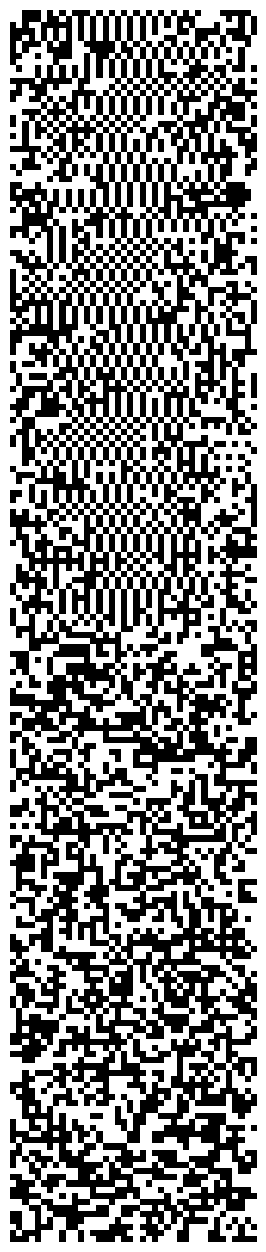

In [2]:
# @title Plotting samples
from matplotlib import pylab as plt

ds = get_binary_dataset(200,
                        needle_length=20,
                        haystack_length=20)

plt.figure(figsize=(4, 16))
plt.spy(ds.tensors[0][:, :, 0].numpy())
plt.axis('off')

## The simplest RNN model

Now we will build a simple RNN-based classifier for binary sequences. We feed the sequence into the RNN, then extract the hidden state activations at the end of the sequence, and finally apply a linear transformation to compute the classifier's output.

An RNN module returns two outputs, as explained in the [documentation](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html). We also need a layer that selects the second output – the hidden state activations at the end of the sequence – and then rearranges and flattens it so that it can be the input to the linear layer.

*Note:* By applying a `sigmoid`, the classifier output can be turned into a probability, similar to how `softmax` works. We will not make sigmoid part of the network, as this makes learning numerically more stable.

In [3]:
# @title RNN Classifier definition

from torch.nn import RNN, Linear, Sequential

class extract_last_cell(torch.nn.Module):
  '''Pytorch module which extracts and flattens the last hidden state of an RNN.
  '''
  def forward(self,x):
    _ , out = x
    return out.permute(1,0,2).flatten(start_dim=1)

def get_basic_RNN_classifier():
  return Sequential(
    RNN(input_size=1, hidden_size=20, num_layers=2, batch_first=True),
    extract_last_cell(),
    Linear(in_features = 20*2, out_features=1)
  )

## Subtask 1: Calculate the value of the loss function

Calculate the log loss (i.e., cross entropy loss or log loss) of the untrained, randomly initialized network on minibatches from the dataset defined above.

*Tips:*
* You can use the [`pytorch/utils/data/DataLoader`](https://pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) class to sample minibatches from the data.
* and/or you can access the contents of the `TensorDataset` directly using the `tensors` attribute.
* Use the [`torch.nn.BCEWithLogitsLoss`](https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) class or the [`torch.nn.functional.binary_cross_entropy_with_logits`](https://pytorch.org/docs/stable/nn.functional.html) function. I recommend reading the documentation.

*5 points*

### Your solution

Use this text cell and the code cell below, or add additional cells if you find it necessary.

In [6]:
loader = DataLoader(ds, batch_size=16)
criterion = torch.nn.BCEWithLogitsLoss()
model = get_basic_RNN_classifier()

all_loss = 0
for x,y in loader:
    logits = model(x)
    loss = criterion(y, logits)
    all_loss += loss.item()

all_loss / len(ds)

0.06193220645189285

## Subtask 2: Calculate false negative probability

As mentioned in the documentation, there is a negligible probability that a negative data point also happens to contain the needle sequence. In such a case, we can call this data point a false negative, because although it contains a needle, it is labeled negative.

Let the needle length be $k$, and the total sequence length be $k+l$. Calculate the probability that a negative sample (a binary sequence of length $k+l$, where $0$ and $1$ are equally likely) is actually positive, i.e., contains the $k$-length sequence $010101\ldots01$. Describe your reasoning. Your solution can be a formula or even a Python function with parameters $k$ and $l$.

*Tip:*
* If you know it, use LaTeX expressions, which you can write between dollar signs.

*10 points*

### Your solution

## The training code

We used the `ignite` framework to write the training code below. First, install the Python module. The code itself is quite long, but it is actually very simple. Below the code, we explain some of its components.

In [7]:
# @title Installing `torch-ignite`
!pip install pytorch-ignite


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# @title Original training code
from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss

def fit_model_basic(model : torch.nn.Module,
                    training_dataset : torch.utils.data.Dataset,
                    test_dataset : torch.utils.data.Dataset) -> torch.nn.Module:
  '''Fits a pytorch model to the training dataset using stochastic gradient
  descent and tracks progress on a test set.

  Arguments
  ---------
  model : pytorch.nn.Module
    pytorch model that can be evaluated on input tensor in the dataset, and
    returns a tensor that matches the shape of the output tensor.
  training_dataset : pytorch.util.data.Dataset
    used to train the model
  test_dataset : pytorch.util.data.Dataset
    used to evaluate the performance of the model at the end of each epoch

  Retuns
  ------
  pytorch.nn.Module
    the model after training
  '''

  train_loader = DataLoader(
      training_dataset,
      batch_size=100,
      shuffle=True
  )
  val_loader = DataLoader(
      test_dataset,
      batch_size=1000,
      shuffle=False,
  )

  optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
  criterion = torch.nn.BCEWithLogitsLoss()

  trainer = create_supervised_trainer(model, optimizer, criterion)

  def thresholded_output_transform(output):
      y_pred, y = output
      y_pred = torch.heaviside(y_pred, values=torch.zeros(1))
      return y_pred, y

  val_metrics = {
      "accuracy": Accuracy(thresholded_output_transform),
      "bce": Loss(criterion)
  }
  evaluator = create_supervised_evaluator(model, metrics=val_metrics)

  @trainer.on(Events.ITERATION_COMPLETED(every=10))
  def log_training_loss(trainer):
      print(f"Epoch[{trainer.state.epoch}] Loss: {trainer.state.output:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_training_results(trainer):
      evaluator.run(train_loader)
      metrics = evaluator.state.metrics
      print(f"Training Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_validation_results(trainer):
      evaluator.run(val_loader)
      metrics = evaluator.state.metrics
      print(f"Validation Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  trainer.run(train_loader, max_epochs=5)

  return model

The above code may seem long and complicated, but that is because we want ignite to log the training progress in detail.

Ignite uses Python decorators (such as `@trainer.on(Events.EPOCH_COMPLETED)`). In Ignite, these decorators are used to register functions that are called when various events occur during training. For example, `@trainer.on(Events.ITERATION_COMPLETED(every=10))` tells ignite to execute the function below it after every 10 iterations.

The above code is largely an adaptation of the example code found in the [ignite documentation](https://pytorch-ignite.ai/tutorials/beginner/01-getting-started/), and we do not need to understand its details now.

Now let's dive in and use our training loop to train a classifier on the generated binary dataset:

In [9]:
# @title First training attempt

ds_train = get_binary_dataset(5000, needle_length=10, haystack_length=10)
ds_test = get_binary_dataset(1000, needle_length=10, haystack_length=10)
rnn_classifier = get_basic_RNN_classifier()

fit_model_basic(rnn_classifier, ds_train, ds_test)

Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.69
Epoch[1] Loss: 0.69
Training Results - Epoch: 1  Avg accuracy: 0.51 Avg loss: 0.69
Validation Results - Epoch: 1  Avg accuracy: 0.55 Avg loss: 0.69
Epoch[2] Loss: 0.69
Epoch[2] Loss: 0.70
Epoch[2] Loss: 0.69
Epoch[2] Loss: 0.69
Epoch[2] Loss: 0.69
Training Results - Epoch: 2  Avg accuracy: 0.49 Avg loss: 0.69
Validation Results - Epoch: 2  Avg accuracy: 0.53 Avg loss: 0.69
Epoch[3] Loss: 0.69
Epoch[3] Loss: 0.69
Epoch[3] Loss: 0.69
Epoch[3] Loss: 0.70
Epoch[3] Loss: 0.69
Training Results - Epoch: 3  Avg accuracy: 0.50 Avg loss: 0.69
Validation Results - Epoch: 3  Avg accuracy: 0.53 Avg loss: 0.69
Epoch[4] Loss: 0.69
Epoch[4] Loss: 0.69
Epoch[4] Loss: 0.69
Epoch[4] Loss: 0.69
Epoch[4] Loss: 0.69
Training Results - Epoch: 4  Avg accuracy: 0.55 Avg loss: 0.69
Validation Results - Epoch: 4  Avg accuracy: 0.56 Avg loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5] Loss: 0.69
Epoch[5]

Sequential(
  (0): RNN(1, 20, num_layers=2, batch_first=True)
  (1): extract_last_cell()
  (2): Linear(in_features=40, out_features=1, bias=True)
)

## Subtask 3: Improve the training code

Well, it seems our training function is not very successful, since by the end of training it only achieves a little over 50% accuracy, meaning it is essentially no better than flipping a coin.

However, with small changes, we can achieve results above 90%.

Improve the training code. Below we have copied the same function as before, named `fit_model_improved`. You will use this function in the following tasks. Make minimal changes to it so that training becomes more successful.
* Add extra arguments to the function to allow tuning important training parameters (such as learning rate).
* You can swap components, for example, choose a different optimization algorithm.
* Document your changes and the method you used to find better parameters.
* Demonstrate that your new version works better.

*5 points*

### Your solution

Rewrite the content of the code cell below, and add additional code and text cells.

In [ ]:
from ignite.engine import Events, create_supervised_trainer, create_supervised_evaluator
from ignite.metrics import Accuracy, Loss

def fit_model_improved(model : torch.nn.Module,
                    training_dataset : torch.utils.data.Dataset,
                    test_dataset : torch.utils.data.Dataset) -> torch.nn.Module:
  
  train_loader = DataLoader(
      training_dataset,
      batch_size=16,
      shuffle=True
  )
  val_loader = DataLoader(
      test_dataset,
      batch_size=16,
      shuffle=False,
  )

  optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)
  criterion = torch.nn.BCEWithLogitsLoss()

  trainer = create_supervised_trainer(model, optimizer, criterion)

  def thresholded_output_transform(output):
      y_pred, y = output
      y_pred = torch.heaviside(y_pred, values=torch.zeros(1))
      return y_pred, y

  val_metrics = {
      "accuracy": Accuracy(thresholded_output_transform),
      "bce": Loss(criterion)
  }
  evaluator = create_supervised_evaluator(model, metrics=val_metrics)

  @trainer.on(Events.ITERATION_COMPLETED(every=10))
  def log_training_loss(trainer):
      print(f"Epoch[{trainer.state.epoch}] Loss: {trainer.state.output:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_training_results(trainer):
      evaluator.run(train_loader)
      metrics = evaluator.state.metrics
      print(f"Training Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  @trainer.on(Events.EPOCH_COMPLETED)
  def log_validation_results(trainer):
      evaluator.run(val_loader)
      metrics = evaluator.state.metrics
      print(f"Validation Results - Epoch: {trainer.state.epoch}  Avg accuracy: {metrics['accuracy']:.2f} Avg loss: {metrics['bce']:.2f}")

  trainer.run(train_loader, max_epochs=50)

  return model

In [31]:
# ds_train = get_binary_dataset(5000, needle_length=10, haystack_length=10)
# ds_test = get_binary_dataset(1000, needle_length=10, haystack_length=10)
# rnn_classifier = get_basic_RNN_classifier()

fit_model_basic(rnn_classifier, ds_train, ds_test)

Epoch[1] Loss: 0.67
Epoch[1] Loss: 0.61
Epoch[1] Loss: 0.51
Epoch[1] Loss: 0.55
Epoch[1] Loss: 0.47
Training Results - Epoch: 1  Avg accuracy: 0.74 Avg loss: 0.52
Validation Results - Epoch: 1  Avg accuracy: 0.76 Avg loss: 0.50
Epoch[2] Loss: 0.78
Epoch[2] Loss: 0.46
Epoch[2] Loss: 0.41
Epoch[2] Loss: 0.40
Epoch[2] Loss: 0.42
Training Results - Epoch: 2  Avg accuracy: 0.90 Avg loss: 0.29
Validation Results - Epoch: 2  Avg accuracy: 0.91 Avg loss: 0.28
Epoch[3] Loss: 0.33
Epoch[3] Loss: 0.32
Epoch[3] Loss: 0.25
Epoch[3] Loss: 0.16
Epoch[3] Loss: 0.28
Training Results - Epoch: 3  Avg accuracy: 0.91 Avg loss: 0.28
Validation Results - Epoch: 3  Avg accuracy: 0.91 Avg loss: 0.28
Epoch[4] Loss: 0.11
Epoch[4] Loss: 0.80
Epoch[4] Loss: 0.20
Epoch[4] Loss: 0.73
Epoch[4] Loss: 0.70
Training Results - Epoch: 4  Avg accuracy: 0.52 Avg loss: 0.70
Validation Results - Epoch: 4  Avg accuracy: 0.52 Avg loss: 0.70
Epoch[5] Loss: 0.69
Epoch[5] Loss: 0.66
Epoch[5] Loss: 0.71
Epoch[5] Loss: 0.66
Epoch[5]

Sequential(
  (0): RNN(1, 20, num_layers=2, batch_first=True)
  (1): extract_last_cell()
  (2): Linear(in_features=40, out_features=1, bias=True)
)

## Subtask 4: Evaluate the model on longer sequences

Our model above was trained on fixed-length strings, but an RNN can process inputs of any length.
* Test whether a successfully trained model can still find the needle in test sequences longer than the training data.
* Document your results with a figure and briefly (1-2 sentences) comment on them.

*5 points*

### Your solution

## Subtask 5: Try other RNN architectures

Try other commonly used RNN architectures mentioned in the preparatory material. Compare their performance in a figure, especially on the longer sequences examined in Subtask 4. Interpret the results and give a brief (1-3 sentence) explanation.

*5 points*

### Your solution

## Subtask 6: Illustrate what the model attends to

In this subtask, we want to understand which part of the input the model uses to make its decision. This problem is often called attribution.

For RNNs, the derivative of the output with respect to the input, and its magnitude, can provide information about this. This method is used [in this Distill article](https://distill.pub/2019/memorization-in-rnns/), and it was also discussed in the preparatory material and in [Feri's notes](https://hackmd.io/QrkitKUITGySbLAzkakzYw), where the vanishing gradients problem is illustrated.

* Compute the gradient of the model's output with respect to the input.
* Visualize it so that it is clear which inputs the model attends to.
* Using your solutions to the other subtasks, compare two situations (e.g., two models, or inputs of different lengths).
* Draw a conclusion and describe what you observe (3-5 sentences).

**Tip:**
* This task can be solved with at most 5-10 lines of PyTorch code.

*10 points*

### Your solution

## Subtask 7: Is it solvable with convolution?

Argue in 3-5 sentences whether you think the problem is solvable with a convolutional network.
* What size and structure of convolutional network would be needed? How many layers, how many filters, what filter size, stride, and padding?
* Which PyTorch layers would you use?
* Do you expect it to work better or worse than an RNN?

*5 points*

### Your solution

## Subtask 8: Train a convolutional network

Based on your observations from the previous subtask, implement and train a CNN, then evaluate it in comparison to the RNNs. Document what you observed (2-4 sentences).

*Tips*:
* Since we are not working with images, other PyTorch layers may be useful than those we have seen before. It is a good idea to carefully explore the [convolutional layers](https://pytorch.org/docs/stable/nn.html#convolution-layers) and [adaptive pooling layers](https://pytorch.org/docs/stable/nn.html#pooling-layers). There may also be utility functions.
* Reading the documentation will also help ensure that the dimensions/shapes of your tensors are correct. Utility layers such as `nn.Flatten` or `nn.Unflatten` may also be useful.
* Don't overcomplicate it; this is a simple task, and the maximum points are awarded for the most minimal solution.

*10 points*

### Your solution

## 9. PyTorch mini-project: Independent exploration

If you have largely solved the other subtasks, now it is up to you what additional extensions you would like to implement related to the topic.
Here are some examples:
* Complicating the data: for example, non-binary, discrete alphabet samples, or multiclass (multiple types of needles).
* Multi-component needle where you need to detect the presence of two substrings simultaneously.
* Pointer Network style: not just telling whether there is a needle, but also its starting position.
* Implementing a Transformer architecture.
* Generative or sequence-to-sequence model.
* Needle in a Haystack computer vision edition.

Each mini-project (you can submit multiple, as long as they are clearly separated) is worth a maximum of *30 points*. The characteristics of a 30-point project are:
* **motivation and creativity:** interesting, creative project, good motivation, clear description of hypotheses/questions/goals, references to literature where relevant.
* **implementation:** non-trivial work demonstrating technical proficiency, correct implementation, good choice of tools, compact and readable code.
* **evaluation and conclusions:** fair and detailed evaluation, excellent use of figures (captions, labels, etc.), concise but impactful conclusion.

*30 points/mini-project*

# Mistral API tasks

In these tasks, you will test the Mistral AI language models using the API, with various self-designed Needle in a Haystack (NIAH) tests.

## Testing the Mistral API

Before the contest, we asked you to obtain an API key from Mistral and add it to Colab. If you have done this, the following code should run. From this code, you can also see how to interact with the model using the API. The API documentation can be found [here](https://docs.mistral.ai/capabilities/completion/).

In [32]:
!pip install mistralai

  Using cached zipp-3.23.1-py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/990.5 kB ? eta -:--:--
   ---------------------------------------- 990.5/990.5 kB 6.6 MB/s  0:00:00
Using cached zipp-3.23.1-py3-none-any.whl (10 kB)

   ----- ---------------------------------- 1/7 [jsonpath-python]
   ----------------- ---------------------- 3/7 [importlib-metadata]
   ----------------- ---------------------- 3/7 [importlib-metadata]
   ---------------------- ----------------- 4/7 [opentelemetry-api]
   ---------------------- ----------------- 4/7 [opentelemetry-api]
   ---------------------- ----------------- 4/7 [opentelemetry-api]
   ------------------------- --------- 5/7 [opentelemetry-semantic-conventions]
   ------------------------- --------- 5/7 [opentelemetry-semantic-conventions]
   ------------------------- --------- 5/7 [opentelemetry-semantic-conventions]
   ------------------------- --------- 5/7 [opentelemetry-semantic-conventions]
   --------


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from mistralai.client import MistralClient
from mistralai.models.chat_completion import ChatMessage
from google.colab import userdata

model = 'open-mistral-7b'
api_key = userdata.get('MISTRAL_API_KEY')
client = MistralClient(api_key=api_key)

messages = [
    ChatMessage(role="user", content="What is the best French cheese?")
]

# No streaming
chat_response = client.chat(
    model=model,
    messages=messages,
)

print(chat_response.choices[0].message.content)

The "best" French cheese can be quite subjective as it depends on personal taste. However, some of the most famous and widely appreciated French cheeses include:

1. Roquefort: A blue cheese made from sheep's milk. It's known for its strong, pungent flavor and crumbly texture.

2. Camembert de Normandie: A soft, creamy cow's milk cheese with a white rind. It's often served at room temperature and has a mild, earthy flavor.

3. Brie de Meaux: Another soft, creamy cow's milk cheese, but with a smooth, spreadable texture. It has a mild, slightly nutty flavor.

4. Comté: A hard, nutty-flavored cheese made from unpasteurized cow's milk. It's often used in cooking and on sandwiches.

5. Reblochon: A soft, washed-rind cow's milk cheese from the Rhône-Alpes region. It's often used in dishes like fondue and tartiflette.

6. Munster: A soft, smelly cheese with a washed rind. It's known for its strong, spicy flavor.

7. Époisses de Bourgogne: A soft, smelly cheese with a washed rind. It's known f

## Subtask 1: Design a NIAH test

Design a simplified Needle in a Haystack (NIAH) test that evaluates the natural language capabilities of the `Mistral open 7B` model. In this test, we insert some short piece of information into relatively long English texts, then ask the model a question that can only be correctly answered based on the inserted information. Design as precisely as possible what text you will use, how you will use the API, how you will evaluate the results, and what performance you expect. Document all this in 5-10 sentences. The perfect solution is a concise specification that allows the test to be reproduced and executed as accurately as possible.

*Tips:*
* Using the [NIAH GitHub repository](https://github.com/gkamradt/LLMTest_NeedleInAHaystack) as-is is not allowed, but it can give you ideas for solving the tasks.
* The [torchtext](https://pytorch.org/text/stable/index.html) library contains several easily accessible text corpora.

*5 points*

### Your solution

Use a text cell.

## Subtask 2: Implement the test

Now implement the test you designed in the previous subtask, using the Mistral API. Ideally, create a figure from the evaluation results, and document your solution and evaluate the results in a few sentences.

* For consistency, use the Mistral 7B open source model!
* Keep the number of input tokens per message below about 1000 tokens, and do not use significantly more than 10,000,000 tokens in total.

*10 points*

### Your solution

Use code and text cells!

## Subtask 3: Design a coding NIAH test

Now, similar to Subtask 1, design a NIAH test, but instead of testing English language skills, test capabilities related to coding/formal languages. So use programming language data or algorithmically generated formal languages. Document it similarly to the first subtask.

*5 points*

### Your solution

## Subtask 4: Implement the test

Now implement the coding NIAH test you designed in the previous subtask, using the Mistral API. Ideally, create a figure from the evaluation results, and document your solution and evaluate the results in a few sentences.

* For consistency, still use the Mistral 7B open source model!
* Keep the number of input tokens per message still below about 1000 tokens, and do not use significantly more than 10,000,000 tokens in total.

*10 points*

### Your solution

## Subtask 5:

Compare the Mistral 7B and Mixtral 8x7B open source models on the NIAH tests. Write 3-5 sentences about the results.

*5 points*

## Your solution

## 6. Mistral mini-project: Independent exploration

If you have largely solved the other Mistral subtasks, now it is up to you what additional extensions you would like to implement related to the topic.
Here are some examples:
* Complicating the test: for example, having two needles that need to be combined to get the correct answer.
* Using the Mistral API's embedding endpoint in some creative way in the needle-in-a-haystack context.
* Successful or unsuccessful detection of syntax errors in C++ code as a function of code length and error position.

Each mini-project (you can submit multiple, as long as they are clearly separated) is worth a maximum of *30 points*. The characteristics of a 30-point project are:
* **motivation and creativity:** interesting, creative project, good motivation, clear description of hypotheses/questions/goals, references to literature where relevant.
* **implementation:** non-trivial work demonstrating technical proficiency, correct implementation, good choice of tools, compact and readable code.
* **evaluation and conclusions:** fair and detailed evaluation, excellent use of figures (captions, labels, etc.), concise but impactful conclusion.

*30 points/mini-project*